# 21_因果推断基础-未测混杂与敏感性分析

## Notebook 使用说明

建议先阅读《03. 因果图、混杂与识别假设》和《08. 双重稳健估计与AIPW》。本篇需要 NumPy、pandas、Matplotlib 和 statsmodels。缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

主线依据参考资料 [1] 第 18.3 节，用两组潜在结局条件均值的比值表示未测混杂，再计算不同假设下的平均效应。后面的线性模型补充对应 [2] 第 12.2 节；两道练习分别对应 [1] 第 18.2 节的最坏情形界限和第 17 章的 E-value。

总体表、收入数据和线性模型数据均为另设的教学构造，不是原书的实证结果。数据与图形由代码生成，不需要外部文件，也不依赖前面 Notebook 的变量或 `notebook_support.py`。主案例仍估计全体人群 ATE；线性模型补充另用连续暴露，并单独说明目标。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells。默认包括 999 次 Bootstrap、两种样本量下各 400 次重复模拟，以及每种样本量 120 份数据各 199 次 Bootstrap 的区间检查。所有重复次数都在初始化单元中设置。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
from pathlib import Path
from itertools import product
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import CenteredNorm
from IPython.display import display
import statsmodels
import statsmodels.api as sm

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_DATA = 42
SEED_BOOT = 2026
SEED_REPEAT = 2027
SEED_COVERAGE = 2028
SEED_LINEAR = 2029
N_MAIN = 3000
N_BOOT = 999
SAMPLE_SIZES = (600, 2400)
N_REPEATS = 400
N_COVERAGE = 120
N_BOOT_COVERAGE = 199
N_LINEAR = 5000
ALPHA = 0.05
Z_CRIT = NormalDist().inv_cdf(1 - ALPHA / 2)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
statsmodels 0.14.6


上一篇的双重稳健，讨论的是结果模型与评分模型能不能拟合对。还有一个更早的问题没有解决：应该调整的变量，是否真的都记录在数据里？

比如，想研究培训能否提高收入。数据里记录了学历，却没有记录家庭支持。家庭支持可能同时影响是否参加培训，以及不参加培训时本来能挣多少钱。只用学历调整，结果回归、加权和 AIPW 可能给出很接近的答案，但这些答案也可能一起偏离培训的真实作用。

下面刻意把一个变量藏起来。先看这个遗漏如何影响结果，再问：两组在看不见的那部分上要有多大差别，才会改变我们的结论？这一次改变的是识别假设，不是回归里多加一个二次项。

## 理论基础

### 1. 两个模型都拟合对，为什么还可能有偏？

仍用 $T\in\{0,1\}$ 表示处理，$X$ 表示已经观察到的处理前变量，$U$ 表示未测混杂变量。目标是

$$
\tau=E[Y(1)-Y(0)].
$$

可能成立的是 $Y(t)\perp T\mid(X,U)$，而不是 $Y(t)\perp T\mid X$。省略 $U$ 后，路径 $T\leftarrow U\to Y$ 仍然存在。[1，第 16.1–16.2 节；2，第 12.1 节]

定义观察数据中的函数

$$
\mu_t(x)=E[Y\mid T=t,X=x],\qquad e(x)=P(T=1\mid X=x).
$$

即使这三个函数都已知，$E_X[\mu_1(X)-\mu_0(X)]$ 也不一定等于 $\tau$。前者是可观察的调整后比较；只有加上相应识别条件，才有因果解释。AIPW 的“双重稳健”不会替我们补上未测变量。[1，第 12 章开头、第 18.1 节]

### 2. 用两组潜在结局的均值差异，表示遗漏有多大

Ding 第 18.3 节使用比值形式的敏感性参数：

$$
\varepsilon_1(x)=
\frac{E[Y(1)\mid T=1,X=x]}{E[Y(1)\mid T=0,X=x]},
\qquad
\varepsilon_0(x)=
\frac{E[Y(0)\mid T=1,X=x]}{E[Y(0)\mid T=0,X=x]}.
$$

两个比值的分子都是实际接受者，分母都是实际未接受者；比较时，潜在处理状态保持相同。这不是 $Y(1)$ 与 $Y(0)$ 的比值，也不是处理的风险比。[1，第 18.3.1 节]

例如，$\varepsilon_0(x)=1.2$ 表示：在相同 $X=x$ 下，即使两组都不参加培训，实际参加者的平均收入仍是实际未参加者的 1.2 倍。$\varepsilon_1$ 则把两组都放在参加培训的状态下比较。

$\varepsilon_1=\varepsilon_0=1$ 回到条件均值可交换的基准。这足以恢复这里的均值识别公式，不等于证明整个条件分布独立。敏感性参数不能从只有 $(X,T,Y)$ 的数据里直接估出来；要根据背景知识预先给定，或者在明确的范围内变化。[1，第 10.3、18.3 节]

本篇主案例的潜在收入为正，均值比值有直接解释。不对收入先中心化：加上常数会改变均值比值，同一个 $\varepsilon$ 就不再表示同一种假设。收入从“千元”换成“元”只涉及正比例缩放，不会改变比值。这是由定义直接得到的尺度检查。

### 3. 固定敏感性参数后，如何补齐均值？

一致性给出 $E[Y(1)\mid T=1,X]=\mu_1(X)$ 和 $E[Y(0)\mid T=0,X]=\mu_0(X)$。另两项由敏感性参数规定：

$$
E[Y(1)\mid T=0,X]=\frac{\mu_1(X)}{\varepsilon_1(X)},
\qquad
E[Y(0)\mid T=1,X]=\mu_0(X)\varepsilon_0(X).
$$

把接受者和未接受者重新合并，就得到 [1，定理 18.1]：

$$
\begin{aligned}
E[Y(1)]&=E\left[TY+(1-T)\frac{\mu_1(X)}{\varepsilon_1(X)}\right],\\
E[Y(0)]&=E\left[T\mu_0(X)\varepsilon_0(X)+(1-T)Y\right].
\end{aligned}
$$

相减并代入拟合值，是书中的 predictive estimator，本篇称“预测式”：观察到的部分用 $Y$，未观察到的部分用调整后的均值。若把观察到的部分也换成 $\widehat\mu_T(X)$，得到 projective estimator，本篇称“投影式”。两者的总体目标相同，有限样本数值不必相同。[1，正文页 250–251]

接下来的流程是：先拟合观察分布，再固定一组 $\varepsilon_0,\varepsilon_1$，计算对应效应；最后改变这两个假设。敏感性分析是在报告“假设为这些值时，答案是什么”，不是让程序选出哪个假设最真实。

## 完整案例一：把未测混杂写进一张总体表

### 1. 四类人，收入和参加概率都给定

下面是自行构造的培训例子。$X$ 表示较高学历，$U$ 表示较强家庭支持。两者都在培训前确定。设

$$
\begin{aligned}
P(X=1)&=0.4,&P(U=1\mid X=x)&=0.2+0.35x,\\
P(T=1\mid X=x,U=u)&=0.12+0.18x+0.50u,\\
b(x,u)&=8+3x+8u,&\tau(x)&=1.5+0.5x.
\end{aligned}
$$

潜在收入以千元计：$Y(0)=b(X,U)V$、$Y(1)=Y(0)+\tau(X)$，其中 $V\sim\operatorname{Uniform}(0.75,1.25)$，在给定 $X,U$ 后与处理抽签独立。由于 $E[V]=1$，两种潜在结局的条件均值分别是 $b(x,u)$ 和 $b(x,u)+\tau(x)$。

这里的 $U$ 不是给原数据随便新增的随机列。它确实参与了处理和潜在收入的生成；等分析时，再把它隐藏。总体 ATE 可以直接算出为 $1.5+0.5\times0.4=1.7$。

In [2]:
x_pop = np.array([0, 1])
p_x = np.array([0.6, 0.4])
q_u = 0.2 + 0.35 * x_pop
population_rows = []
for x_value, px, qu in zip(x_pop, p_x, q_u):
    for u_value in (0, 1):
        joint = px * (qu if u_value == 1 else 1 - qu)
        e_xu = 0.12 + 0.18*x_value + 0.50*u_value
        base = 8 + 3*x_value + 8*u_value
        tau_x = 1.5 + 0.5*x_value
        population_rows.append({"X": x_value, "U": u_value,
                                "总体比例": joint, "处理概率": e_xu,
                                "E[Y(0)|X,U]": base, "E[Y(1)|X,U]": base+tau_x})
population = pd.DataFrame(population_rows)
population_ate = float(p_x @ (1.5 + 0.5*x_pop))
np.testing.assert_allclose(population["总体比例"].sum(), 1)
display(population.round(4))
print(f"总体 ATE = {population_ate:.3f} 千元")

,X,U,总体比例,处理概率,"E[Y(0)|X,U]","E[Y(1)|X,U]"
0,0,0,0.48,0.12,8,9.5
1,0,1,0.12,0.62,16,17.5
2,1,0,0.18,0.30,11,13.0
3,1,1,0.22,0.80,19,21.0


总体 ATE = 1.700 千元


### 2. 隐藏 $U$ 后，每组实际是什么人？

令 $q(x)=P(U=1\mid X=x)$，$e_u(x)=P(T=1\mid X=x,U=u)$。把 $U$ 混合掉，再用贝叶斯公式：

$$
\begin{aligned}
e(x)&=\{1-q(x)\}e_0(x)+q(x)e_1(x),\\
a_1(x)&=P(U=1\mid T=1,X=x)=\frac{q(x)e_1(x)}{e(x)},\\
a_0(x)&=P(U=1\mid T=0,X=x)=\frac{q(x)\{1-e_1(x)\}}{1-e(x)}.
\end{aligned}
$$

因此，相同学历下，参加者与未参加者的家庭支持比例不同。对这个教学模型，四个均值都是 $8+3x+8a_t(x)$ 再加相应的培训效应。下面把它们全部算出来；只有模拟时才知道未观察到的两列。

In [3]:
e_u0 = 0.12 + 0.18*x_pop
e_u1 = e_u0 + 0.50
e_x = (1-q_u)*e_u0 + q_u*e_u1
a1 = q_u*e_u1/e_x
a0 = q_u*(1-e_u1)/(1-e_x)
base_x, tau_x = 8+3*x_pop, 1.5+0.5*x_pop
mu0_pop = base_x + 8*a0
mu1_pop = base_x + 8*a1 + tau_x
cf0_pop = base_x + 8*a1                 # E[Y(0)|T=1,X]
cf1_pop = base_x + 8*a0 + tau_x         # E[Y(1)|T=0,X]
eps0_true = cf0_pop / mu0_pop
eps1_true = mu1_pop / cf1_pop

conditional_table = pd.DataFrame({
    "X": x_pop, "P(T=1|X)": e_x, "P(U=1|T=1,X)": a1,
    "P(U=1|T=0,X)": a0, "mu0 可观察": mu0_pop, "mu1 可观察": mu1_pop,
    "Y(0)均值|T=1 不可观察": cf0_pop, "Y(1)均值|T=0 不可观察": cf1_pop,
    "epsilon0 真值": eps0_true, "epsilon1 真值": eps1_true,
}).set_index("X")
display(conditional_table.round(4))

,P(T=1|X),"P(U=1|T=1,X)","P(U=1|T=0,X)",mu0 可观察,mu1 可观察,Y(0)均值|T=1 不可观察,Y(1)均值|T=0 不可观察,epsilon0 真值,epsilon1 真值
X,,,,,,,,,
0,0.220,0.5636,0.0974,8.7795,14.0091,12.5091,10.2795,1.4248,1.3628
1,0.575,0.7652,0.2588,13.0706,19.1217,17.1217,15.0706,1.3099,1.2688


$X=0$ 时，较强家庭支持者在参加组占约 56.4%，在未参加组只占约 9.7%。即使两组都不培训，收入也有差异；对应 $\varepsilon_0(0)\approx1.425$、$\varepsilon_1(0)\approx1.363$。

两个敏感性参数并不相同，而且都随 $X$ 变化。后面令 $\varepsilon_0=\varepsilon_1=\kappa$ 只是便于画一条曲线的工作假设，不能说这个模拟的真实参数就是某一个 $\kappa$。

### 3. 连观察均值都知道，基准估计仍然有偏

这里没有拟合误差。分别算不调整的组间差、只调整 $X$ 的总体比较，再代入真实的敏感性函数补齐反事实均值。

In [4]:
p_t = float(p_x @ e_x)
raw_difference = (p_x @ (e_x*mu1_pop))/p_t - (p_x @ ((1-e_x)*mu0_pop))/(1-p_t)
x_adjusted_limit = float(p_x @ (mu1_pop-mu0_pop))
corrected_limit = float(p_x @ (
    e_x*mu1_pop + (1-e_x)*mu1_pop/eps1_true
    - e_x*mu0_pop*eps0_true - (1-e_x)*mu0_pop
))
np.testing.assert_allclose(corrected_limit, population_ate, atol=1e-12)
display(pd.DataFrame({"总体计算": ["不调整的组间均值差", "仅调整X，假定epsilon=1",
                               "给定真实epsilon(X)", "直接平均潜在效应"],
                      "结果（千元）": [raw_difference, x_adjusted_limit,
                                      corrected_limit, population_ate]}).set_index("总体计算").round(4))

,结果（千元）
总体计算,
不调整的组间均值差,7.3346
仅调整X，假定epsilon=1,5.5582
给定真实epsilon(X),1.7000
直接平均潜在效应,1.7000


只调整学历时，即使 $e(X),\mu_0(X),\mu_1(X)$ 全部已知，答案仍约为 5.558，而不是 1.7。差异来自未测的家庭支持，不是样本不够大，也不是 Logistic 回归拟合得不好。

## 把公式写成程序

### 1. 预测式、投影式，以及加权形式

定义敏感性修正因子 [1，定理 18.2]：

$$
w_1(X)=e(X)+\frac{1-e(X)}{\varepsilon_1(X)},
\qquad w_0(X)=e(X)\varepsilon_0(X)+1-e(X).
$$

HT 型敏感性估计为

$$
\widehat\tau_{\mathrm{HT,SA}}=
\frac1n\sum_i\left\{\widehat w_{1i}\frac{T_iY_i}{\widehat e_i}
-\widehat w_{0i}\frac{(1-T_i)Y_i}{1-\widehat e_i}\right\}.
$$

结合两类模型，可得 [1，正文页 252]：

$$
\widehat\tau_{\mathrm{DR,SA}}=
\widehat\tau_{\mathrm{HT,SA}}
-\frac1n\sum_i(T_i-\widehat e_i)
\left\{\frac{\widehat\mu_{1i}}{\widehat e_i\varepsilon_{1i}}
+\frac{\widehat\mu_{0i}\varepsilon_{0i}}{1-\widehat e_i}\right\}.
$$

这里的稳健性以“敏感性函数给定且符合实际”为前提：评分模型或结果均值模型正确，可得到相应的一致性；敏感性假设本身错误，不在这个保证内。[1，第 18.3.1 节]

附件有一处需要先说明：正文页 252 的增广项用减号，但页 253 的 `OS_est_sa` 代码用了加号，与该正文公式不一致。本篇采用正文的减号，并用 $\varepsilon_0=\varepsilon_1=1$ 时恢复上一篇 AIPW 的恒等式核对。另核对了原书引用的 Lu–Ding 论文版本 [3] 第 3.2 节，其公式也是减号。这里不照搬冲突的 R 代码，也不据它复现表 18.2。

In [5]:
def positive_vector(value, n: int, name: str):
    """敏感性参数允许标量或长度为 n 的向量；不做静默截断。"""
    a = np.asarray(value, dtype=float)
    if a.ndim == 0:
        a = np.full(n, float(a))
    if a.shape != (n,) or not np.all(np.isfinite(a)) or np.any(a <= 0):
        raise ValueError(f"{name} 必须是正的有限标量或长度为 {n} 的向量。")
    return a


def sensitivity_scores(treatment, outcome, propensity, mu0, mu1,
                       epsilon0=1.0, epsilon1=1.0):
    """返回逐人贡献。调用方再求平均；不读取 U 或任何潜在结局。"""
    t, y, e, m0, m1 = [np.asarray(v, dtype=float)
                       for v in (treatment, outcome, propensity, mu0, mu1)]
    if t.ndim != 1 or len(t) < 2 or any(a.shape != t.shape for a in (y, e, m0, m1)):
        raise ValueError("五个观察/预测输入必须是等长一维向量。")
    if any(not np.all(np.isfinite(a)) for a in (t, y, e, m0, m1)):
        raise ValueError("输入包含缺失值或无穷大。")
    if not np.all(np.isin(t, [0, 1])) or len(np.unique(t)) != 2:
        raise ValueError("T 必须是同时包含 0、1 的二元处理。")
    if np.any((e <= 0) | (e >= 1)):
        raise ValueError("评分必须严格在 (0,1) 内；不能用静默截断代替重叠检查。")
    e0 = positive_vector(epsilon0, len(t), "epsilon0")
    e1 = positive_vector(epsilon1, len(t), "epsilon1")
    w1, w0 = e+(1-e)/e1, e*e0+1-e
    pred = t*y + (1-t)*m1/e1 - t*m0*e0 - (1-t)*y
    proj = t*m1 + (1-t)*m1/e1 - t*m0*e0 - (1-t)*m0
    ht = w1*t*y/e - w0*(1-t)*y/(1-e)
    dr = ht - (t-e)*(m1/(e*e1) + m0*e0/(1-e))
    return np.column_stack([pred, proj, ht, dr])

SA_NAMES = ["预测式", "投影式", "HT-SA", "DR-SA"]
# 使用任意预测值，而不是恰好残差为零的饱和拟合，检查退化恒等式。
t_check = np.array([1, 0, 1, 0, 0, 1])
y_check = np.array([12., 7., 16., 9., 11., 19.])
e_check = np.array([.2, .3, .4, .5, .6, .7])
m0_check, m1_check = np.arange(6.)+8, np.arange(6.)+10
s_check = sensitivity_scores(t_check, y_check, e_check, m0_check, m1_check)
aipw_check = m1_check-m0_check+t_check*(y_check-m1_check)/e_check-(1-t_check)*(y_check-m0_check)/(1-e_check)
np.testing.assert_allclose(s_check[:, 3], aipw_check, atol=1e-12)
print("epsilon0=epsilon1=1 时，DR-SA 的逐人贡献与 AIPW 完全一致。")

epsilon0=epsilon1=1 时，DR-SA 的逐人贡献与 AIPW 完全一致。


### 2. 在完整总体分布上核对，而不只看一次随机结果

把前面的每一类 $X$ 再按 $T=0,1$ 展开。用真实敏感性函数，然后分别把结果均值或评分换成有偏的工作函数。逐人公式先按 $T$ 求期望，再按总体比例求平均。

这一步只是程序和定理的核对，不是现实中能用 $U$ 来“调参”。它也能排除一种错误：把敏感性修正当成简单地从 AIPW 中减去某个常数。

In [6]:
x_enum = np.repeat(x_pop, 2)
t_enum = np.tile([0, 1], 2)
e_enum = e_x[x_enum]
p_enum = p_x[x_enum] * np.where(t_enum == 1, e_enum, 1-e_enum)
m0_enum, m1_enum = mu0_pop[x_enum], mu1_pop[x_enum]
y_enum = np.where(t_enum == 1, m1_enum, m0_enum)
e0_enum, e1_enum = eps0_true[x_enum], eps1_true[x_enum]
checks = []
for label, q, m0, m1 in [
    ("两类观察模型都对", e_enum, m0_enum, m1_enum),
    ("仅观察评分对", e_enum, m0_enum+2, m1_enum-3),
    ("仅观察均值对", np.full(4, .4), m0_enum, m1_enum),
    ("两类都偏移", np.full(4, .4), m0_enum+2, m1_enum-3),
]:
    values = p_enum @ sensitivity_scores(t_enum, y_enum, q, m0, m1, e0_enum, e1_enum)
    if label != "两类都偏移":
        np.testing.assert_allclose(values[3], population_ate, atol=1e-12)
    checks.append(dict(设定=label, **dict(zip(SA_NAMES, values))))
display(pd.DataFrame(checks).set_index("设定").round(5))

,预测式,投影式,HT-SA,DR-SA
设定,,,,
两类观察模型都对,1.70000,1.70000,1.70000,1.70000
仅观察评分对,-0.71089,-3.07289,1.70000,1.70000
仅观察均值对,1.70000,1.70000,1.30779,1.70000
两类都偏移,-0.71089,-3.07289,1.30779,1.72669


## 完整案例二：有限样本中隐藏一个变量

### 1. 生成数据，把观察数据与真值分开保存

只把 `X、T、Y` 交给主分析。`U、Y0、Y1` 放在 `truth` 中，后面仅用于核对遗漏的影响。真实研究中不存在这张可以随时打开的答案表。

In [7]:
def make_hidden_data(n: int, seed: int):
    if not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError("n 必须是至少 20 的整数。")
    rng = np.random.default_rng(seed)
    x = rng.binomial(1, .4, size=n)
    u = rng.binomial(1, .2+.35*x)
    e_xu = .12+.18*x+.50*u
    t = rng.binomial(1, e_xu)
    v = rng.uniform(.75, 1.25, size=n)
    y0 = (8+3*x+8*u)*v
    y1 = y0+1.5+.5*x
    observed = pd.DataFrame({"X": x, "T": t, "Y": np.where(t == 1, y1, y0)})
    truth = pd.DataFrame({"U": u, "Y0": y0, "Y1": y1, "e_XU": e_xu})
    return observed, truth

observed, truth = make_hidden_data(N_MAIN, SEED_DATA)
x, t, y = [observed[name].to_numpy() for name in ("X", "T", "Y")]
display(observed.head(8).round(3))
display(pd.crosstab(observed["X"], observed["T"]).rename(columns={0: "未参加", 1: "参加"}))
print(f"样本量={len(observed)}；总体 ATE={population_ate:.3f}；本样本潜在效应均值={(truth.Y1-truth.Y0).mean():.3f}")

,X,T,Y
0,1,0,13.055
1,0,0,6.984
2,1,1,20.895
3,1,0,8.413
4,0,0,6.036
5,1,0,12.130
6,1,0,8.901
7,1,0,19.454


T,未参加,参加
X,,
0,1427,389
1,503,681


样本量=3000；总体 ATE=1.700；本样本潜在效应均值=1.697


### 2. 对观察分布用饱和拟合，避免把遗漏与函数形式混在一起

$X$ 只有两层，直接用各层处理比例估计 $e(X)$，用各层两组均值估计 $\mu_0(X),\mu_1(X)$。这与二元 $X$ 上带截距的 Logistic 评分、以及 `Y ~ 1 + T + X + T*X` 的 OLS 结果拟合分别等价。

这样选模型有一个目的：观察到的分布不需要用一个过于简单的函数近似。后面仍然有偏，不能再归咎于遗漏二次项。下面用 `bincount` 实现同样的分组计算，以便多次 Bootstrap；它不是另一个机器学习算法。

In [8]:
def saturated_fit(group, treatment, outcome):
    """离散组内估计概率和两种观察均值。组编号必须从 0 连续开始。"""
    g, t0, y0 = [np.asarray(v) for v in (group, treatment, outcome)]
    if g.ndim != 1 or len(g) < 4 or t0.shape != g.shape or y0.shape != g.shape:
        raise ValueError("分组、处理、结局必须是等长的一维向量。")
    if any(not np.all(np.isfinite(v)) for v in (g, t0, y0)):
        raise ValueError("不接受缺失或无穷值。")
    if np.any(g < 0) or np.any(g != g.astype(int)) or not np.all(np.isin(t0, [0, 1])):
        raise ValueError("分组必须是非负整数，T 必须为 0 或 1。")
    g, t0 = g.astype(int), t0.astype(int)
    k = int(g.max())+1
    count = np.bincount(2*g+t0, minlength=2*k).reshape(k, 2)
    if np.any(count < 2):
        raise ValueError("每层两组至少各 2 人；本函数不删除空层或自动合并。")
    sums = np.bincount(2*g+t0, weights=y0, minlength=2*k).reshape(k, 2)
    means = sums/count
    return {"count": count, "pi": count.sum(axis=1)/len(g),
            "e": count[:, 1]/count.sum(axis=1), "mu0": means[:, 0], "mu1": means[:, 1]}


def cell_coefficients(fit):
    """投影式的 A、各层 B_x、C_x；预测式在本饱和拟合下与其相同。"""
    pi, e, m0, m1 = [fit[s] for s in ("pi", "e", "mu0", "mu1")]
    a = np.sum(pi*(e*m1-(1-e)*m0))
    return np.r_[a, pi*(1-e)*m1, pi*e*m0]


def evaluate_coefficients(coefficients, epsilon0=1.0, epsilon1=1.0):
    """支持一份系数或多次重抽样系数；最后一维为 1+2*K。"""
    c = np.asarray(coefficients, dtype=float)
    if c.ndim not in (1, 2) or c.shape[-1] < 3 or c.shape[-1] % 2 != 1 or not np.all(np.isfinite(c)):
        raise ValueError("系数必须为有限的一维或二维数组，末维长度为 1+2*K。")
    k = (c.shape[-1]-1)//2
    e0, e1 = positive_vector(epsilon0, k, "epsilon0"), positive_vector(epsilon1, k, "epsilon1")
    return c[..., 0]+np.sum(c[..., 1:1+k]/e1, axis=-1)-np.sum(c[..., 1+k:]*e0, axis=-1)

fit_x = saturated_fit(x, t, y)
e_hat, mu0_hat, mu1_hat = [fit_x[s][x] for s in ("e", "mu0", "mu1")]
coef_main = cell_coefficients(fit_x)
# 与熟悉的回归接口独立核对，而不在循环中重复做同一个数值优化。
A = np.column_stack([np.ones(len(x)), t, x, t*x])
ols = sm.OLS(y, A).fit()
logit = sm.GLM(t, np.column_stack([np.ones(len(x)), x]), family=sm.families.Binomial()).fit()
np.testing.assert_allclose(ols.fittedvalues, np.where(t == 1, mu1_hat, mu0_hat), atol=1e-9)
np.testing.assert_allclose(logit.fittedvalues, e_hat, atol=1e-9)
print("分组均值与交互 OLS、分组概率与 Logistic 拟合一致。")

分组均值与交互 OLS、分组概率与 Logistic 拟合一致。


### 3. 多种方法一致，是不是就放心了？

先按 $\varepsilon=1$ 计算。然后打开模拟答案表：一项用完整 $(X,U)$ 调整，另一项仍只拟合 $X$，但给入前面由总体构造得到的真实 $\varepsilon(X)$。后两项都是理想对照，不是现实分析里额外找来的模型。

In [9]:
base_sa = sensitivity_scores(t, y, e_hat, mu0_hat, mu1_hat)
reg_x = np.mean(mu1_hat-mu0_hat)
ipw_x = np.mean(t*y/e_hat-(1-t)*y/(1-e_hat))
aipw_x = base_sa[:, 3].mean()
np.testing.assert_allclose([reg_x, ipw_x, aipw_x], reg_x, atol=1e-10)

group_xu = 2*x + truth["U"].to_numpy()
fit_xu = saturated_fit(group_xu, t, y)
full_oracle = float(fit_xu["pi"] @ (fit_xu["mu1"]-fit_xu["mu0"]))
sa_true = sensitivity_scores(t, y, e_hat, mu0_hat, mu1_hat,
                             eps0_true[x], eps1_true[x]).mean(axis=0)
np.testing.assert_allclose(sa_true, evaluate_coefficients(coef_main, eps0_true, eps1_true), atol=1e-10)
main_results = pd.DataFrame({
    "分析": ["不调整", "仅X：结果回归", "仅X：HT", "仅X：AIPW",
             "完整X,U（理想对照）", "仅X+真实epsilon(X)（理想对照）"],
    "估计": [y[t == 1].mean()-y[t == 0].mean(), reg_x, ipw_x, aipw_x, full_oracle, sa_true[3]],
}).set_index("分析")
main_results["估计－总体ATE"] = main_results["估计"]-population_ate
display(main_results.round(4))

,估计,估计－总体ATE
分析,,
不调整,7.2698,5.5698
仅X：结果回归,5.3364,3.6364
仅X：HT,5.3364,3.6364
仅X：AIPW,5.3364,3.6364
"完整X,U（理想对照）",1.6855,-0.0145
仅X+真实epsilon(X)（理想对照）,1.5654,-0.1346


默认样本中，只用 $X$ 的结果回归、HT 与 AIPW 都是约 5.336；完整调整为约 1.686，给入真实敏感性函数为约 1.565。后两项仍有抽样误差，不会每次都恰好等于 1.7。

前三种调整方法一致，是离散饱和拟合的数值恒等式，上一份练习已经见过；它们不是三个独立证据。完整调整和真实敏感性函数两项，则都在处理刚才遗漏的组间差异。

### 4. 已测变量平衡了，未测变量呢？

沿用第六篇的 ATE 权重和固定标准化分母。实际诊断只能看 $X$；本次模拟额外画出 $U$，让遗漏变得可见。把 $U$ 的结果标为“仅模拟可见”，不要误以为真实资料也能做这项检查。[1，第 11.3、16.2 节]

,调整前,按X评分加权后
X（实际可见）,0.81586,-0.00000
U（仅模拟可见）,1.36452,1.15611


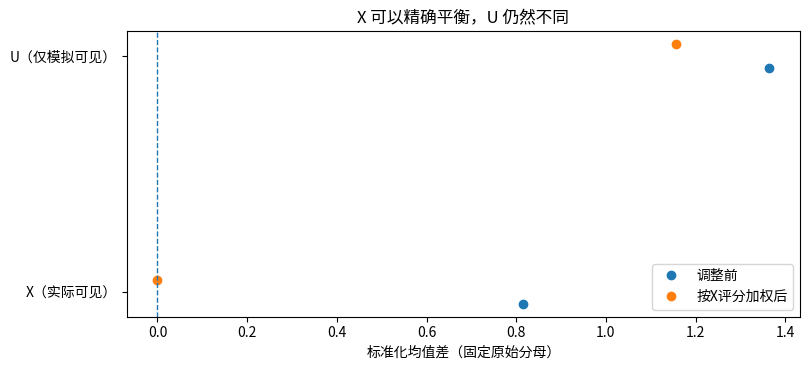

In [10]:
def weighted_smd(value, treatment, weights):
    v, z, w = [np.asarray(a) for a in (value, treatment, weights)]
    d = np.sqrt((v[z == 1].var(ddof=1)+v[z == 0].var(ddof=1))/2)
    if d <= 0:
        raise ValueError("原始两组的合并标准差必须为正。")
    return (np.average(v[z == 1], weights=w[z == 1])
            - np.average(v[z == 0], weights=w[z == 0]))/d

weights_x = np.where(t == 1, 1/e_hat, 1/(1-e_hat))
balance = pd.DataFrame({
    name: [weighted_smd(v, t, np.ones(len(t))), weighted_smd(v, t, weights_x)]
    for name, v in [("X（实际可见）", x), ("U（仅模拟可见）", truth["U"].to_numpy())]
}, index=["调整前", "按X评分加权后"]).T
display(balance.round(5))
fig, ax = plt.subplots(figsize=(8.2, 3.8))
for j, label in enumerate(balance.columns):
    ax.plot(balance[label], np.arange(len(balance))+.10*(j-.5), "o", label=label)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(np.arange(len(balance)), balance.index)
ax.set(xlabel="标准化均值差（固定原始分母）", title="X 可以精确平衡，U 仍然不同")
ax.legend()
fig.tight_layout()
plt.show()

## 敏感性分析：同一份资料，不同反事实假设

### 1. 先画两参数的结果

仍只使用 $(X,T,Y)$。为便于展示，暂时把两个函数分别设成常数，让 $\varepsilon_0,\varepsilon_1$ 在 0.85–1.65 之间变化。这是教学范围，不是从数据得到的可信范围，更不是适用于任何研究的推荐阈值。

主拟合中三种均值相关的敏感性估计相同，加上 HT-SA 也相同；下面直接利用分组结果计算，不在每个网格位置重复拟合观察模型。敏感性参数改变的是反事实均值，观察数据和对应拟合并没有变化。

epsilon0,1.0,1.1,1.2,1.4,1.6
epsilon1,,,,,
1.0,5.336,4.931,4.525,3.714,2.903
1.1,4.463,4.057,3.652,2.841,2.030
1.2,3.735,3.329,2.924,2.113,1.302
1.4,2.590,2.185,1.779,0.968,0.157
1.6,1.732,1.327,0.921,0.110,-0.701


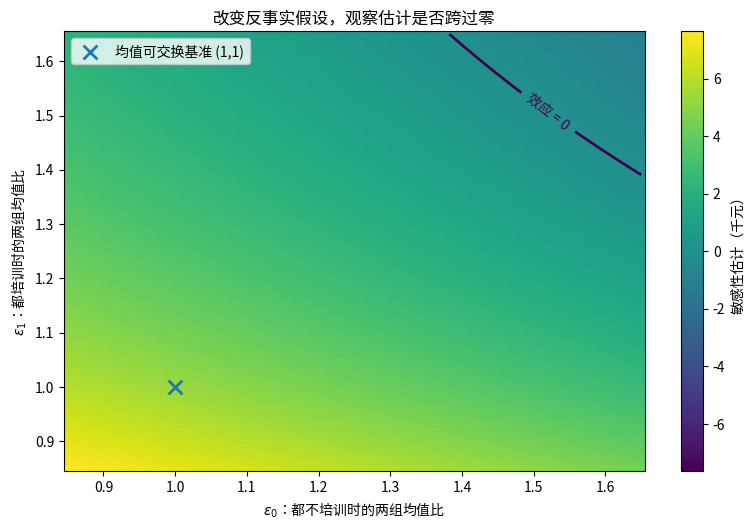

In [11]:
eps_grid = np.linspace(.85, 1.65, 81)
sensitivity_surface = np.array([
    [evaluate_coefficients(coef_main, e0, e1) for e0 in eps_grid]
    for e1 in eps_grid
])
selected = [1.0, 1.1, 1.2, 1.4, 1.6]
display(pd.DataFrame(
    [[evaluate_coefficients(coef_main, e0, e1) for e0 in selected] for e1 in selected],
    index=pd.Index(selected, name="epsilon1"), columns=pd.Index(selected, name="epsilon0")
).round(3))

fig, ax = plt.subplots(figsize=(8.1, 5.4))
mesh = ax.pcolormesh(eps_grid, eps_grid, sensitivity_surface, shading="nearest", norm=CenteredNorm())
fig.colorbar(mesh, ax=ax, label="敏感性估计（千元）")
contour = ax.contour(eps_grid, eps_grid, sensitivity_surface, levels=[0], linewidths=2)
ax.clabel(contour, fmt={0: "效应 = 0"}, inline=True)
ax.scatter([1], [1], marker="x", s=100, linewidths=2, label="均值可交换基准 (1,1)")
ax.set(xlabel=r"$\varepsilon_0$：都不培训时的两组均值比",
       ylabel=r"$\varepsilon_1$：都培训时的两组均值比",
       title="改变反事实假设，观察估计是否跨过零")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

在这个正收入例子里，增大 $\varepsilon_0$ 会提高参加者的反事实未培训收入；增大 $\varepsilon_1$ 会降低未参加者的反事实培训收入。两者都使培训效应下降。这与参数的方向定义一致，不是程序自动判断“存在正混杂”。

零等高线表示哪些假设组合会使点估计降到零。它没有告诉我们实际隐藏变量位于哪一点。模拟真值是随 $X$ 变化的两对参数，也不能硬放成常数参数图上的单个“真实点”。

### 2. 沿着相同均值比的路径，分开看估计与抽样误差

令 $\varepsilon_0=\varepsilon_1=\kappa$。在本例的饱和拟合下，预测式、投影式、HT-SA 与 DR-SA 相同，且都可整理成

$$
\widehat\tau(\kappa)=A+\frac{B}{\kappa}-C\kappa,
$$

其中 $A=n^{-1}\sum_i(2T_i-1)Y_i$，$B=n^{-1}\sum_i(1-T_i)\widehat\mu_{1i}$，$C=n^{-1}\sum_iT_i\widehat\mu_{0i}$。这是为本篇加速计算整理的恒等式，不是额外统计假设。

Bootstrap 每次重抽完整的 $(X,T,Y)$ 行，重新计算各层人数、评分和结果均值。一次拟合后可同时评价整条 $\kappa$ 曲线。[1，第 18.3 节、练习 18.3、附录 A.6]

In [12]:
def bootstrap_coefficients(group, treatment, outcome, n_boot: int, seed: int):
    if not isinstance(n_boot, (int, np.integer)) or n_boot < 2:
        raise ValueError("n_boot 必须是至少 2 的整数。")
    g, z, yy = [np.asarray(a) for a in (group, treatment, outcome)]
    original = saturated_fit(g, z, yy)  # 先检查输入和各层样本量
    rng = np.random.default_rng(seed)
    result = np.empty((n_boot, 1+2*len(original["pi"])))
    for b in range(n_boot):
        idx = rng.integers(0, len(g), size=len(g))
        fitted = saturated_fit(g[idx], z[idx], yy[idx])
        result[b] = cell_coefficients(fitted)
    return result

boot_main = bootstrap_coefficients(x, t, y, N_BOOT, SEED_BOOT)
kappa_grid = np.linspace(.85, 1.65, 161)
path_values = np.array([evaluate_coefficients(coef_main, k, k) for k in kappa_grid])
boot_path = np.column_stack([evaluate_coefficients(boot_main, k, k) for k in kappa_grid])
path_se = boot_path.std(axis=0, ddof=1)
path_lower, path_upper = path_values-Z_CRIT*path_se, path_values+Z_CRIT*path_se
A_main, B_main, C_main = coef_main[0], coef_main[1:3].sum(), coef_main[3:].sum()
kappa_zero = (A_main + np.sqrt(A_main**2+4*B_main*C_main))/(2*C_main)
np.testing.assert_allclose(evaluate_coefficients(coef_main, kappa_zero, kappa_zero), 0, atol=1e-10)
print(f"完成 {N_BOOT} 次整行重拟合 Bootstrap。")
print(f"沿 epsilon0=epsilon1=kappa，点估计为零的 kappa = {kappa_zero:.4f}")

完成 999 次整行重拟合 Bootstrap。
沿 epsilon0=epsilon1=kappa，点估计为零的 kappa = 1.5127


,估计,Bootstrap_SE,95%下限,95%上限
固定假设,,,,
kappa=1.00,5.3364,0.1628,5.0173,5.6555
kappa=1.20,2.9236,0.1520,2.6257,3.2215
kappa=1.40,0.9684,0.1469,0.6804,1.2564
kappa=1.60,-0.7007,0.1460,-0.9868,-0.4146
真实epsilon(X)，仅模拟核对,1.5654,0.1473,1.2768,1.8540


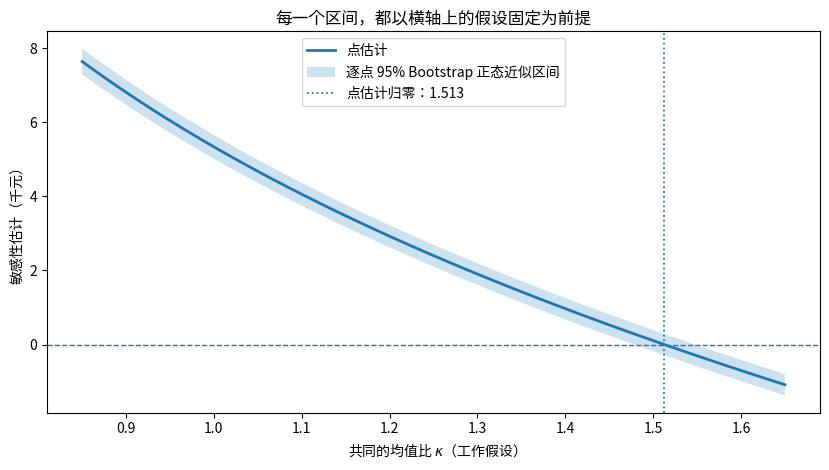

若只考虑预设假设集合 [1,1.4]×[1,1.4]，点估计范围： [0.9684 5.3364]


In [13]:
path_rows = []
for label, e0, e1 in [(f"kappa={k:.2f}", k, k) for k in (1, 1.2, 1.4, 1.6)]+[
    ("真实epsilon(X)，仅模拟核对", eps0_true, eps1_true)
]:
    est = float(evaluate_coefficients(coef_main, e0, e1))
    se = float(evaluate_coefficients(boot_main, e0, e1).std(ddof=1))
    path_rows.append({"固定假设": label, "估计": est, "Bootstrap_SE": se,
                      "95%下限": est-Z_CRIT*se, "95%上限": est+Z_CRIT*se})
path_table = pd.DataFrame(path_rows).set_index("固定假设")
display(path_table.round(4))

fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.plot(kappa_grid, path_values, linewidth=2, label="点估计")
ax.fill_between(kappa_grid, path_lower, path_upper, alpha=.22, label="逐点 95% Bootstrap 正态近似区间")
ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(kappa_zero, linestyle=":", linewidth=1.3, label=f"点估计归零：{kappa_zero:.3f}")
ax.set(xlabel=r"共同的均值比 $\kappa$（工作假设）", ylabel="敏感性估计（千元）",
       title="每一个区间，都以横轴上的假设固定为前提")
ax.legend()
fig.tight_layout()
plt.show()

assumption_corners = np.array([evaluate_coefficients(coef_main, e0, e1)
                               for e0, e1 in product([1., 1.4], repeat=2)])
print("若只考虑预设假设集合 [1,1.4]×[1,1.4]，点估计范围：",
      np.round([assumption_corners.min(), assumption_corners.max()], 4))

默认样本中，$\kappa=1$ 的区间约为 [5.017, 5.656]；使用真实 $\varepsilon(X)$ 的区间约为 [1.277, 1.854]。沿常数路径，点估计在 $\kappa\approx1.513$ 时归零；这个数不是对真实敏感性参数的估计。

这里有三种不同的范围，不能混写。曲线上某一点的置信区间，表示固定敏感性假设后的抽样不确定性；整条曲线随横轴移动，表示改变假设的影响；预设矩形内点估计的最小值到最大值，只是该假设集合对应的估计范围，不是 95% 置信区间。

阴影也是逐点区间，不是整条曲线的同时置信带。参数范围覆盖模拟真值与否，不能靠这些区间来判断。若给定的 $\varepsilon$ 不符合实际，区间再窄也可能不覆盖真实 ATE。

## 重复模拟：更多数据，会不会把遗漏的问题冲淡？

### 1. 同样的生成机制，改变样本量

每种样本量重新生成 400 份数据。比较三项：只用 $X$ 且设 $\varepsilon=1$、给入真实 $\varepsilon(X)$、直接把 $U$ 纳入完整调整。后两项仅是理想对照。

评价目标始终是总体 ATE 1.7，而不是每次样本的潜在效应均值。这样才能把研究对象的抽样变化也计入误差。先看点估计，下一节另做完整的区间检查。

In [14]:
REPEAT_METHODS = ["仅X，epsilon=1", "仅X+真实epsilon(X)", "完整X,U"]
rng_repeat = np.random.default_rng(SEED_REPEAT)
repeat_records = []
for n in SAMPLE_SIZES:
    for r in range(N_REPEATS):
        d, oracle = make_hidden_data(n, int(rng_repeat.integers(0, 2**31)))
        xx, tt, yy = [d[s].to_numpy() for s in ("X", "T", "Y")]
        f = saturated_fit(xx, tt, yy)
        cf = cell_coefficients(f)
        f_full = saturated_fit(2*xx+oracle["U"].to_numpy(), tt, yy)
        estimates = [evaluate_coefficients(cf),
                     evaluate_coefficients(cf, eps0_true, eps1_true),
                     f_full["pi"] @ (f_full["mu1"]-f_full["mu0"])]
        for label, value in zip(REPEAT_METHODS, estimates):
            repeat_records.append({"n": n, "重复": r, "方法": label, "估计": value})
repeated = pd.DataFrame(repeat_records)
print(f"完成 {len(SAMPLE_SIZES)} 种样本量，每种 {N_REPEATS} 份独立数据。")

完成 2 种样本量，每种 400 份独立数据。


平均估计      偏差    经验SD    RMSE  偏差MC_SE
n    方法                                                      
600  仅X，epsilon=1     5.5882  3.8882  0.3753  3.9063   0.0188
     仅X+真实epsilon(X)  1.7257  0.0257  0.3436  0.3441   0.0172
     完整X,U            1.7006  0.0006  0.1951  0.1948   0.0098
2400 仅X，epsilon=1     5.5661  3.8661  0.1947  3.8710   0.0097
     仅X+真实epsilon(X)  1.7061  0.0061  0.1762  0.1761   0.0088
     完整X,U            1.7030  0.0030  0.0925  0.0924   0.0046

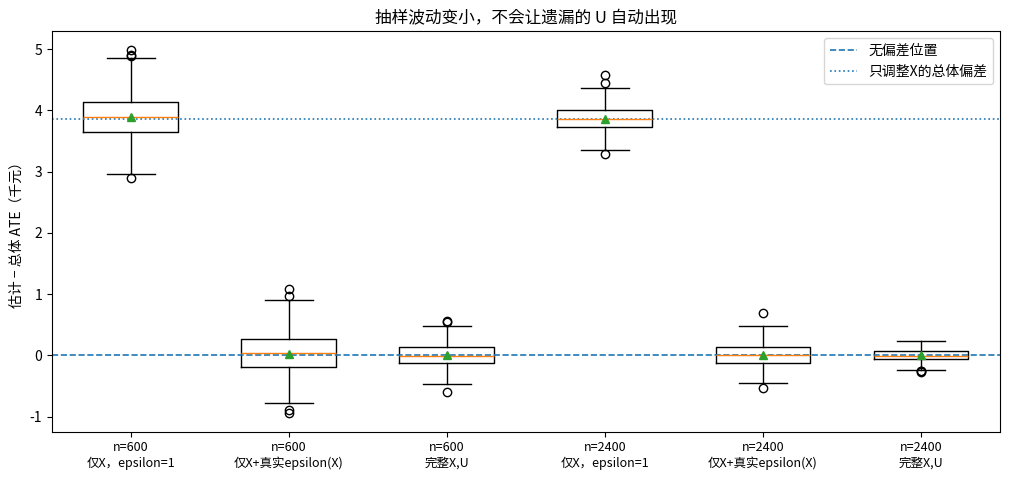

In [15]:
repeat_summary = []
for (n, label), group in repeated.groupby(["n", "方法"], sort=False):
    error = group["估计"].to_numpy()-population_ate
    repeat_summary.append({"n": n, "方法": label, "平均估计": group["估计"].mean(),
                           "偏差": error.mean(), "经验SD": error.std(ddof=1),
                           "RMSE": np.sqrt(np.mean(error**2)),
                           "偏差MC_SE": error.std(ddof=1)/np.sqrt(len(error))})
repeat_table = pd.DataFrame(repeat_summary).set_index(["n", "方法"])
display(repeat_table.round(4))

box_values, box_labels = [], []
for n in SAMPLE_SIZES:
    for label in REPEAT_METHODS:
        values = repeated.loc[(repeated.n == n) & (repeated["方法"] == label), "估计"]
        box_values.append(values.to_numpy()-population_ate)
        box_labels.append(f"n={n}\n{label}")
fig, ax = plt.subplots(figsize=(10.2, 4.9))
ax.boxplot(box_values, tick_labels=box_labels, widths=.6, showmeans=True)
ax.axhline(0, linestyle="--", linewidth=1.2, label="无偏差位置")
ax.axhline(x_adjusted_limit-population_ate, linestyle=":", linewidth=1.2,
           label="只调整X的总体偏差")
ax.set(ylabel="估计 − 总体 ATE（千元）", title="抽样波动变小，不会让遗漏的 U 自动出现")
ax.tick_params(axis="x", labelsize=9)
ax.legend()
fig.tight_layout()
plt.show()

只用 $X$ 时，估计围绕的仍是约 5.558；样本增加，分布变窄，但相对于 1.7 的偏差没有消失。这一次不是两类工作模型同时写错，而是条件均值可交换的基准不成立。

两种理想对照都应围绕同一个目标，不过其波动不必一样。给入真实敏感性函数相当于提供了额外信息；不能据此宣称它在真实研究中比记录 $U$ 更优。

### 2. 每份数据重新做区间，看看覆盖了什么

另生成每种样本量各 120 份独立研究。每份做 199 次 Bootstrap，重新拟合观察分布，分别在 $\varepsilon=1$ 和固定的真实 $\varepsilon(X)$ 下构造区间。这里只改变识别假设，两种分析使用相同的重抽样行。

报告覆盖次数、覆盖率和平均区间宽度。覆盖率的 Monte Carlo 误差与单份研究的标准误不同；尤其是 0 次覆盖，不等于真实覆盖概率已被证明严格等于零。

In [16]:
rng_coverage = np.random.default_rng(SEED_COVERAGE)
coverage_records = []
for n in SAMPLE_SIZES:
    for r in range(N_COVERAGE):
        seed_data, seed_boot = [int(s) for s in rng_coverage.integers(0, 2**31, size=2)]
        d, _ = make_hidden_data(n, seed_data)
        xx, tt, yy = [d[s].to_numpy() for s in ("X", "T", "Y")]
        cf = cell_coefficients(saturated_fit(xx, tt, yy))
        bs = bootstrap_coefficients(xx, tt, yy, N_BOOT_COVERAGE, seed_boot)
        for label, e0, e1 in [("仅X，epsilon=1", 1., 1.),
                               ("仅X+真实epsilon(X)", eps0_true, eps1_true)]:
            estimate = float(evaluate_coefficients(cf, e0, e1))
            se = float(evaluate_coefficients(bs, e0, e1).std(ddof=1))
            low, high = estimate-Z_CRIT*se, estimate+Z_CRIT*se
            coverage_records.append({"n": n, "方法": label, "估计": estimate,
                                     "SE": se, "宽度": high-low,
                                     "覆盖": low <= population_ate <= high})
coverage = pd.DataFrame(coverage_records)
print(f"完成 {len(SAMPLE_SIZES)*N_COVERAGE} 份研究，每份 {N_BOOT_COVERAGE} 次重拟合 Bootstrap。")

完成 240 份研究，每份 199 次重拟合 Bootstrap。


覆盖次数  研究次数     覆盖率    MC下限    MC上限  点估计经验SD  平均Bootstrap_SE  平均区间宽度
n    方法                                                                                  
600  仅X，epsilon=1        0   120  0.0000  0.0000  0.0310   0.4148          0.3800  1.4897
     仅X+真实epsilon(X)   107   120  0.8917  0.8234  0.9356   0.3817          0.3463  1.3573
2400 仅X，epsilon=1        0   120  0.0000  0.0000  0.0310   0.1974          0.1895  0.7427
     仅X+真实epsilon(X)   112   120  0.9333  0.8739  0.9658   0.1779          0.1726  0.6765

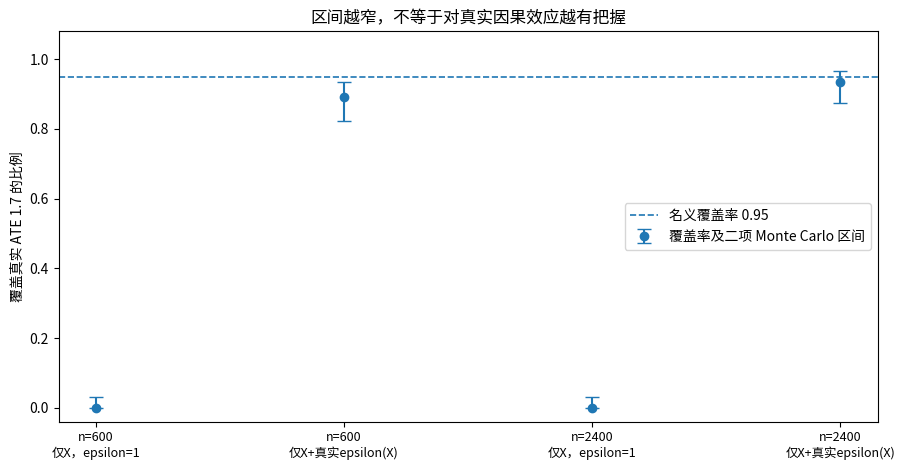

In [17]:
def wilson_interval(success: int, total: int, z=Z_CRIT):
    """二项模拟比例的 Wilson 区间，避免零次覆盖时显示零误差。"""
    if total < 1 or not 0 <= success <= total:
        raise ValueError("覆盖次数必须位于 0 到总次数之间。")
    p = success/total
    center = (p+z*z/(2*total))/(1+z*z/total)
    half = z*np.sqrt(p*(1-p)/total+z*z/(4*total**2))/(1+z*z/total)
    return max(0., center-half), min(1., center+half)

coverage_rows = []
for (n, label), group in coverage.groupby(["n", "方法"], sort=False):
    hits, total = int(group["覆盖"].sum()), len(group)
    mc_low, mc_high = wilson_interval(hits, total)
    coverage_rows.append({"n": n, "方法": label, "覆盖次数": hits, "研究次数": total,
                          "覆盖率": hits/total, "MC下限": mc_low, "MC上限": mc_high,
                          "点估计经验SD": group["估计"].std(ddof=1),
                          "平均Bootstrap_SE": group.SE.mean(), "平均区间宽度": group["宽度"].mean()})
coverage_table = pd.DataFrame(coverage_rows).set_index(["n", "方法"])
display(coverage_table.round(4))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
pos = np.arange(len(coverage_table))
rate = coverage_table["覆盖率"].to_numpy()
yerr = np.vstack([np.maximum(0, rate-coverage_table.MC下限),
                  np.maximum(0, coverage_table.MC上限-rate)])
ax.errorbar(pos, rate, yerr=yerr, fmt="o", capsize=5, label="覆盖率及二项 Monte Carlo 区间")
ax.axhline(.95, linestyle="--", linewidth=1.2, label="名义覆盖率 0.95")
ax.set_xticks(pos, [f"n={n}\n{label}" for n, label in coverage_table.index])
ax.set(ylabel="覆盖真实 ATE 1.7 的比例", ylim=(-.04, 1.08),
       title="区间越窄，不等于对真实因果效应越有把握")
ax.tick_params(axis="x", labelsize=9)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()

图中的误差线描述“这 120 次模拟得到的覆盖比例”有多精确，用的是二项比例的 Wilson 区间；不是再给单份培训效应加一个区间。该显示是本篇为模拟比例增加的统计补充，不来自书中的敏感性参数定义。

默认运行中，基准分析在两种样本量下都是 0/120 次覆盖真实 ATE。使用真实敏感性函数时，分别为 107/120 和 112/120，即约 0.892 和 0.933；尤其是 600 人时，结果低于名义覆盖率 0.95，不能把它写成“已验证精确 95% 覆盖”。

这些是正态近似区间，199 次 Bootstrap 得到的标准误和 120 次研究得到的覆盖率也都有模拟误差。要区分有限样本近似与模拟波动，需要增加研究次数和 Bootstrap 次数；不能仅凭敏感性参数给对就保证有限样本区间准确。参数给错时，即使标准误正确描述了有偏估计量的波动，区间也可能漏掉真正目标。

## 补充：在线性模型里，用偏 R² 表示混杂强度

### 1. 先把目标换清楚

第二本书第 12.2 节给出另一种参数化。这里另用连续暴露 $T$，不再是是否参加培训；$\alpha$ 表示暴露增加一个单位的恒定因果效应。它不是主案例二元处理 ATE 的另一套直接公式。

按该节的部分线性结构写为

$$
Y=\alpha T+\delta U+f_Y(X)+\epsilon_Y,\quad
T=\gamma U+f_T(X)+\epsilon_T,\quad
U=f_U(X)+\epsilon_U.
$$

给定 $X$，误差均值为零、互不相关，且 $E[\epsilon_U^2]=1$。分别去掉能由 $X$ 预测的部分后，仅调整 $X$ 的回归系数为 [2，例 12.2.1]：

$$
\beta=\alpha+\phi,\qquad
\phi=\frac{\delta\gamma}{\gamma^2+E[\epsilon_T^2]}.
$$

令 $r_T=R^2_{T\sim U\mid X}$、$r_Y=R^2_{Y\sim U\mid T,X}$。第二个量衡量在 $T,X$ 已经进入模型后，$U$ 还能解释多少剩余结局变异；不是 $Y$ 与 $U$ 的简单相关系数平方。[2，定理 12.2.1]

$$
\phi^2=\frac{r_Yr_T}{1-r_T}
\frac{E[(\widetilde Y-\beta\widetilde T)^2]}{E[\widetilde T^2]}.
$$

因此，可以根据可观察的残差尺度，对两个未知的偏 R² 给出假设，再计算可能的偏差大小。下面使用线性 $f$，所有去除步骤都由 OLS 完成，不提前引入 DML。

In [18]:
rng_linear = np.random.default_rng(SEED_LINEAR)
x1_lin, x2_lin, eu, et, ey = rng_linear.normal(size=(5, N_LINEAR))
u_lin = .7*x1_lin+.3*x2_lin+eu
T_lin = .9*u_lin+.8*x1_lin-.4*x2_lin+et
Y_lin = .8*T_lin+1.4*u_lin+1.2*x1_lin+.5*x2_lin+1.5*ey
X_lin = np.column_stack([np.ones(N_LINEAR), x1_lin, x2_lin])
A_short = np.column_stack([X_lin, T_lin])
A_long = np.column_stack([X_lin, T_lin, u_lin])
short_fit = sm.OLS(Y_lin, A_short).fit()
long_fit = sm.OLS(Y_lin, A_long).fit()
t_short = sm.OLS(T_lin, X_lin).fit()
t_long = sm.OLS(T_lin, np.column_stack([X_lin, u_lin])).fit()

beta_short, beta_long = float(short_fit.params[-1]), float(long_fit.params[-2])
r_t_true_sample = 1-t_long.ssr/t_short.ssr
r_y_true_sample = 1-long_fit.ssr/short_fit.ssr
residual_scale = short_fit.ssr/t_short.ssr
bias_from_r2 = np.sqrt(r_y_true_sample*r_t_true_sample/(1-r_t_true_sample)*residual_scale)
np.testing.assert_allclose(bias_from_r2, abs(beta_short-beta_long), atol=1e-10)
linear_summary = pd.Series({
    "结构因果系数 alpha": .8, "总体遗漏偏差 phi": 1.4*.9/(.9**2+1),
    "仅调整X的样本系数": beta_short, "完整调整X,U的样本系数": beta_long,
    "两系数之差": beta_short-beta_long, "偏R2公式恢复的差的绝对值": bias_from_r2,
    "r_T（仅模拟可见）": r_t_true_sample, "r_Y（仅模拟可见）": r_y_true_sample,
}, name="结果")
display(linear_summary.to_frame().round(5))

,结果
结构因果系数 alpha,0.80000
总体遗漏偏差 phi,0.69613
仅调整X的样本系数,1.47094
"完整调整X,U的样本系数",0.77116
两系数之差,0.69978
偏R2公式恢复的差的绝对值,0.69978
r_T（仅模拟可见）,0.45840
r_Y（仅模拟可见）,0.31600


这里的“两个样本系数之差”与偏 R² 公式可以精确核对，但二者都不是有限样本中已知的总体偏差。总体偏差另由生成式算出为 $1.4\times0.9/(0.9^2+1)\approx0.696$。

### 2. 不观察 $U$ 时，画假设强度与偏差的对应关系

若只愿意假定 $r_T\le a$、$r_Y\le b$，用上面的残差尺度代入，得到偏差界限的点估计

$$
\widehat B(a,b)=\sqrt{\frac{ab}{1-a}\,\widehat S},
\qquad\widehat S=\frac{\sum_i\widehat r_{Y,i}^2}{\sum_i\widehat r_{T,i}^2}.
$$

方向未知时，$\widehat\beta\pm\widehat B$ 是假设下的效应界限估计，不是置信区间。本补充与原书这段一样只讨论点估计敏感性，不给它贴上“95%”。[2，正文页 331–332]

还可以把一个已测变量暂时当成遗漏变量，计算其偏 R² 作参照。但“未测因素不比已测因素强”仍是额外假设，不能由参照数值自动推出。[2，例 12.2.2 及其页边说明]

已测X1的参照（控制其余变量后）：r_T=0.5423，r_Y=0.1730


,r_T上界,r_Y上界,偏差上界估计,系数下界估计,系数上界估计
0,0.05,0.05,0.0694,1.4015,1.5404
1,0.10,0.10,0.1426,1.3283,1.6136
2,0.30,0.30,0.4852,0.9858,1.9561
3,0.60,0.80,1.4823,-0.0113,2.9532


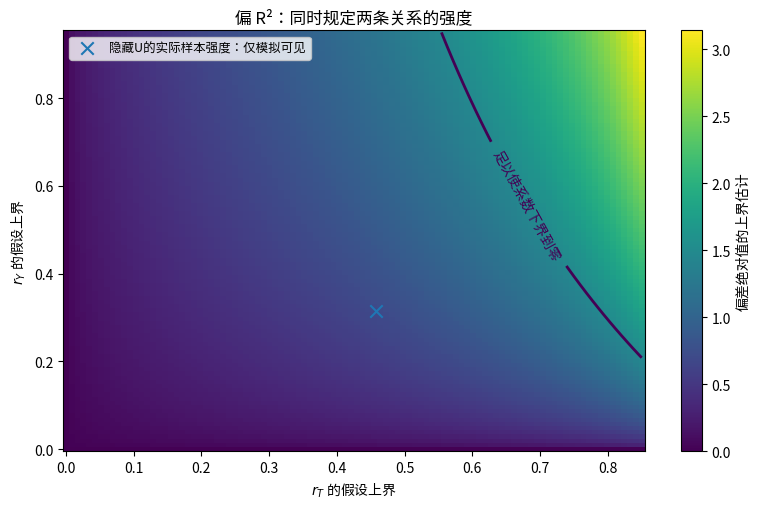

In [19]:
def r2_bias_bound(r_t, r_y, scale):
    rt, ry, ss = np.broadcast_arrays(np.asarray(r_t, float), np.asarray(r_y, float), np.asarray(scale, float))
    if (not all(np.all(np.isfinite(a)) for a in (rt, ry, ss)) or
        np.any((rt < 0) | (rt >= 1)) or np.any((ry < 0) | (ry > 1)) or np.any(ss < 0)):
        raise ValueError("要求 0<=r_T<1、0<=r_Y<=1、scale>=0，且均有限。")
    return np.sqrt(rt*ry/(1-rt)*ss)

# 以 X1 为可观察参照：剩余控制只含 X2；不把它当作隐藏 U 的上界。
base_t = sm.OLS(T_lin, np.column_stack([np.ones(N_LINEAR), x2_lin])).fit()
base_y = sm.OLS(Y_lin, np.column_stack([np.ones(N_LINEAR), T_lin, x2_lin])).fit()
rt_bench = 1-t_short.ssr/base_t.ssr
ry_bench = 1-short_fit.ssr/base_y.ssr
print(f"已测X1的参照（控制其余变量后）：r_T={rt_bench:.4f}，r_Y={ry_bench:.4f}")
assumed_bounds = []
for a, b in [(.05, .05), (.10, .10), (.30, .30), (.60, .80)]:
    bound = float(r2_bias_bound(a, b, residual_scale))
    assumed_bounds.append({"r_T上界": a, "r_Y上界": b, "偏差上界估计": bound,
                           "系数下界估计": beta_short-bound, "系数上界估计": beta_short+bound})
display(pd.DataFrame(assumed_bounds).round(4))

rt_grid, ry_grid = np.linspace(0, .85, 100), np.linspace(0, .95, 100)
bound_surface = r2_bias_bound(rt_grid[None, :], ry_grid[:, None], residual_scale)
fig, ax = plt.subplots(figsize=(8.1, 5.2))
mesh = ax.pcolormesh(rt_grid, ry_grid, bound_surface, shading="nearest")
fig.colorbar(mesh, ax=ax, label="偏差绝对值的上界估计")
cont = ax.contour(rt_grid, ry_grid, bound_surface, levels=[abs(beta_short)], linewidths=2)
ax.clabel(cont, fmt={abs(beta_short): "足以使系数下界到零"}, inline=True)
ax.scatter([r_t_true_sample], [r_y_true_sample], marker="x", s=80, label="隐藏U的实际样本强度：仅模拟可见")
ax.set(xlabel=r"$r_T$ 的假设上界", ylabel=r"$r_Y$ 的假设上界", title="偏 R²：同时规定两条关系的强度")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## 练习

### 1. 什么都不假定，只知道结局在 0 到 1 之间，能说多少？

回到二元处理和二元结局。Ding 第 18.2 节的方法是不补一个具体预测，而是让缺失的潜在结局分别取允许的最小值与最大值。对已给定的有限样本：

$$
\begin{aligned}
L&=\frac1n\sum_i\{T_iY_i-(1-T_i)Y_i-T_i\},\\
U&=\frac1n\sum_i\{T_iY_i+(1-T_i)-(1-T_i)Y_i\}.
\end{aligned}
$$

区间长度为 1。它是所有完整潜在结局表允许的效应界限，不是抽样置信区间。[1，第 18.2 节，表 18.1]

请对下面 8 人表枚举缺失的 8 个潜在结局，共 $2^8=256$ 种填法，核对最小和最大平均效应。再想想：若是没有已知上界的连续收入，能否把样本最大收入直接当作所有反事实的上界？

In [20]:
t_bound = np.array([1, 1, 1, 1, 0, 0, 0, 0])
y_bound = np.array([1, 1, 1, 0, 1, 0, 0, 0])
missing_values = np.array(list(product([0., 1.], repeat=len(t_bound))))
all_y1 = np.where(t_bound == 1, y_bound, missing_values)
all_y0 = np.where(t_bound == 0, y_bound, missing_values)
all_ates = (all_y1-all_y0).mean(axis=1)
lower_bound = np.mean(t_bound*y_bound-(1-t_bound)*y_bound-t_bound)
upper_bound = np.mean(t_bound*y_bound+(1-t_bound)-(1-t_bound)*y_bound)
np.testing.assert_allclose([all_ates.min(), all_ates.max()], [lower_bound, upper_bound])
np.testing.assert_allclose(upper_bound-lower_bound, 1)
bounds_table = pd.DataFrame({"T": t_bound, "Y": y_bound,
    "Y1最低": np.where(t_bound == 1, y_bound, 0), "Y1最高": np.where(t_bound == 1, y_bound, 1),
    "Y0最低": np.where(t_bound == 0, y_bound, 0), "Y0最高": np.where(t_bound == 0, y_bound, 1)})
display(bounds_table)
print(f"观察均值差：{y_bound[t_bound == 1].mean()-y_bound[t_bound == 0].mean():.2f}")
print(f"256 种完整表的平均效应范围：[{lower_bound:.2f}, {upper_bound:.2f}]")

,T,Y,Y1最低,Y1最高,Y0最低,Y0最高
0,1,1,1,1,0,1
1,1,1,1,1,0,1
2,1,1,1,1,0,1
3,1,0,0,0,0,1
4,0,1,0,1,1,1
5,0,0,0,1,0,0
6,0,0,0,1,0,0
7,0,0,0,1,0,0


观察均值差：0.50
256 种完整表的平均效应范围：[-0.25, 0.75]


观察均值差是 0.50，允许的平均效应却从 −0.25 到 0.75，包含零和负值。数据没有给出缺失的一半，仅靠换一种拟合工具，不能把这个范围压成唯一真值。

二元结局的 0、1 是已知支持集；样本最小值和最大值不是连续潜在结局的已知支持集。用观察到的最大收入限制未观察到的反事实，需要另加实质假设，不能因为它便于计算就默认成立。

### 2. E-value：解释掉风险比，需要多强的混杂？

本题用另设的二元结局汇总表。这里没有 $X$，等价于把 $X$ 视为常量；因此不把未调整 RR 冒充已经调整过许多变量的 RR。

先按 Ding 第 17.1 节的二元隐藏变量、无效应解释，定义 $a=RR_{TU}$、$b=RR_{UY}$。其上界为

$$
RR_{TY}^{\mathrm{obs}}\le\frac{ab}{a+b-1}.
$$

对 $R=RR_{TY}^{\mathrm{obs}}>1$，要完全解释掉观察关联，至少需要 $\max(a,b)\ge E(R)$，其中

$$
E(R)=R+\sqrt{R(R-1)}.
$$

当两条关联设成同样强，即 $a=b$，临界值恰好是 $E(R)$。一般情况下，不是要求两条关联都达到 E-value；一条更强，另一条可以更弱，但要满足联合约束。[1，定理 17.1、定义 17.1]

请手写函数计算点估计和靠近无效值 1 的置信限对应的 E-value。$RR<1$ 时先交换处理标签，用倒数；区间已经包含 1 时，靠近无效值的 E-value 记为 1。这个端点规则是把书中第 17.2、17.4.3 节的说明落实成程序，并不是 E-value 自身的置信区间。

In [21]:
def e_value(rr):
    r = np.asarray(rr, dtype=float)
    if not np.all(np.isfinite(r)) or np.any(r <= 0):
        raise ValueError("RR 必须是正的有限值；零风险情况需单独处理。")
    r = np.maximum(r, 1/r)
    return r+np.sqrt(r*(r-1))


def e_value_with_ci(rr: float, lower: float, upper: float):
    if not np.all(np.isfinite([rr, lower, upper])) or not 0 < lower <= rr <= upper:
        raise ValueError("要求 0<lower<=RR<=upper，且输入均有限。")
    closest = 1. if lower <= 1 <= upper else (lower if rr > 1 else upper)
    return float(e_value(rr)), float(e_value(closest))

# 教学数据：每组 400 人，事件分别为 80 和 40；不是随机试验。
n1_rr, n0_rr, events1, events0 = 400, 400, 80, 40
risk1, risk0 = events1/n1_rr, events0/n0_rr
rr = risk1/risk0
se_log_rr = np.sqrt(1/events1-1/n1_rr+1/events0-1/n0_rr)
rr_lower, rr_upper = np.exp(np.log(rr)+np.array([-1, 1])*Z_CRIT*se_log_rr)
ev_point, ev_limit = e_value_with_ci(rr, rr_lower, rr_upper)
rr_rows = []
for label, r, low, high in [
    ("原处理标签", rr, rr_lower, rr_upper),
    ("交换处理标签", 1/rr, 1/rr_upper, 1/rr_lower),
    ("另设一个跨1的区间", 1.1, .8, 1.5),
]:
    point, limit = e_value_with_ci(r, low, high)
    rr_rows.append({"例子": label, "RR": r, "RR下限": low, "RR上限": high,
                    "点估计E-value": point, "靠近1的限值E-value": limit})
display(pd.DataFrame(rr_rows).set_index("例子").round(4))
print(f"同一小表：RD={risk1-risk0:.3f}；RR={rr:.3f}；OR={(risk1/(1-risk1))/(risk0/(1-risk0)):.3f}")

,RR,RR下限,RR上限,点估计E-value,靠近1的限值E-value
例子,,,,,
原处理标签,2.0,1.4047,2.8476,3.4142,2.1586
交换处理标签,0.5,0.3512,0.7119,3.4142,2.1586
另设一个跨1的区间,1.1,0.8000,1.5000,1.4317,1.0000


同一小表：RD=0.100；RR=2.000；OR=2.250


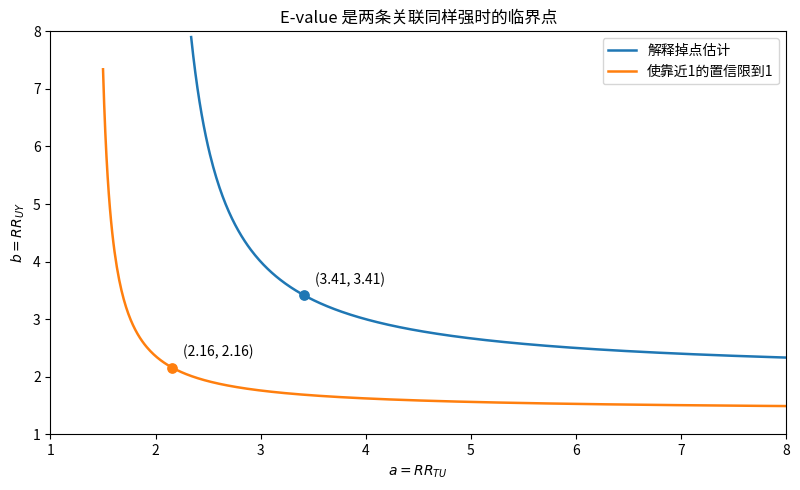

,a,b,ab/(a+b-1),上界至少达到观察RR
0,3.4142,3.4142,2.0000,True
1,5.0000,2.7000,2.0149,True
2,2.1000,2.1000,1.3781,False


In [22]:
fig, ax = plt.subplots(figsize=(8.1, 5.0))
for R, label in [(rr, "解释掉点估计"), (rr_lower, "使靠近1的置信限到1")]:
    a_values = np.linspace(R+.03, 8., 600)
    b_values = R*(a_values-1)/(a_values-R)
    valid = b_values <= 8
    ax.plot(a_values[valid], b_values[valid], label=label, linewidth=1.8)
    E = float(e_value(R))
    ax.scatter([E], [E], s=45)
    ax.annotate(f"({E:.2f}, {E:.2f})", (E, E), xytext=(8, 8), textcoords="offset points")
ax.set(xlim=(1, 8), ylim=(1, 8), xlabel=r"$a=RR_{TU}$", ylabel=r"$b=RR_{UY}$",
       title="E-value 是两条关联同样强时的临界点")
ax.legend()
fig.tight_layout()
plt.show()

joint_examples = [(ev_point, ev_point), (5., 2.7), (2.1, 2.1)]
display(pd.DataFrame([
    {"a": a, "b": b, "ab/(a+b-1)": a*b/(a+b-1),
     "上界至少达到观察RR": bool(a*b/(a+b-1) >= rr-1e-12)}
    for a, b in joint_examples
]).round(4))

点估计 $RR=2$ 的 E-value 约为 3.414。组合 $(5,2.7)$ 的联合上界也超过 2，尽管第二条关联小于 3.414；这说明不能把 E-value 解释成“两边必须同时至少这么大”。联合上界够大只是必要的强度条件，仍不能证明现实中确有这样的混杂因素。

本题的 OR 为 2.25，与 RR=2 并不相同，不能直接把 OR 塞进 RR 公式。[1，第 17.4.2 节] 对 Logistic 系数讨论了罕见结局下的近似；本题已有风险和人数，直接计算 RR，不使用该近似。

E-value 不是 p 值，也不是“因果关系成立的概率”。它评价在所讨论的未测混杂框架下，解释观察关联需要的强度；不能据此排除测量、样本选择等其他问题。其大小还需结合已经调整的变量和领域知识解释，不能跨研究只按数值排可靠性。[1，第 17.5 节]

## 小结

结果回归、加权和 AIPW 可以一致，却共同依赖一个不成立的可交换性假设。主案例用饱和拟合排除了函数形式问题，仍看到了未测混杂；增加样本只是让这个有偏比较更精确。

敏感性分析把看不见的差异写成明确参数。Ding 的均值比值框架直接规定两项反事实均值；线性模型的偏 R² 框架则规定遗漏因素还能解释多少残差变异；E-value 用风险比尺度描述解释掉关联所需的联合强度。三者的参数和目标不同，不应把一个框架的数值直接搬到另一个框架。

报告时应交代：敏感性参数的定义与方向、范围的依据、哪些结果只针对固定假设，以及结论在何处改变。模拟中能打开 $U$ 核对，不代表真实研究能够估计这些隐藏参数。下一篇把目前的设计、诊断、估计与解释连起来，进入真实数据综合案例。

## 参考资料与本篇改写范围

[1] Peng Ding. *A First Course in Causal Inference*. 上传文件《因果推断.pdf》，arXiv:2305.18793v2，2023-10-03。第 16.1–16.2 节用于未测混杂与可忽略性的限制；第 18.1–18.3 节用于反事实均值分解、最坏情形界限、敏感性参数及估计式；第 18.4 节练习 18.3 与附录 A.6 用于 Bootstrap。第 18 章正文页 247–255，对应 PDF 页 273–281。第 17.1–17.2、17.4.2–17.5 节用于 RR、E-value、处理标签互换与解释限制，正文页 231–243，对应 PDF 页 257–269。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传文件《CausalML_book_2022.pdf》，扉页版本 0.1.2，2026-05-03。第 12.1–12.2 节：未测混杂导致的不可识别性、部分线性结构中的遗漏偏差、偏 R² 表达与基准比较。正文页 328–332，对应 PDF 页 338–342。本篇没有使用该书的 Darfur 数据或声称复现其实证系数。

[3] Sizhu Lu and Peng Ding. *Flexible sensitivity analysis for causal inference in observational studies subject to unmeasured confounding*. arXiv:2305.17643v2，2024-03-29，第 3.2 节。作为额外核对来源，只用于检查附件第 18.3 节正文公式与示例代码的符号冲突；本文实现采用正文和该论文一致的减号。地址：`https://arxiv.org/html/2305.17643v2`。

[4] statsmodels 官方 OLS、二项 GLM 接口文档，用于程序核对及线性模型补充；实际执行版本见开头输出。地址：`https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html`；`https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html`。

改写范围说明：四类人总体表、收入生成机制、饱和拟合的快速计算、偏 R² 的模拟参数、二元结局小表、重复模拟和覆盖率图均为本篇教学补充，不是原书实证结果。置信区间使用固定敏感性函数下的重拟合 Bootstrap 正态近似；不把网格的极值范围当成置信区间，不通过寻找最有利的参数来证明因果。本篇没有复现附件中存在公式/代码不一致的表 18.2。